In [1]:
%pip install pytest


   ------------- -------------------------- 1/3 [iniconfig]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   ---------------------------------------- 3/3 [pytest]

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
%pip install shap

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv.csv")

In [5]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df["MultipleLines"].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["customerID"].duplicated().sum()

np.int64(0)

In [16]:
df["Dependents"].count()

np.int64(7043)

In [17]:
df["Dependents"].nunique()

2

In [18]:
df[df["Churn"]=="Yes"].sum()

customerID          3668-QPYBK9237-HQITU9305-CDSKC7892-POOKP0280-X...
gender              MaleFemaleFemaleFemaleMaleFemaleMaleMaleMaleMa...
SeniorCitizen                                                     476
Partner             NoNoNoYesNoYesNoNoYesYesNoNoNoNoNoNoYesNoNoNoY...
Dependents          NoNoNoNoNoYesNoNoYesYesYesNoNoNoNoNoNoNoNoYesN...
tenure                                                          33603
PhoneService        YesYesYesYesYesYesNoYesYesNoYesYesYesYesYesYes...
MultipleLines       NoNoYesYesYesNoNo phone serviceNoYesNo phone s...
InternetService     DSLFiber opticFiber opticFiber opticFiber opti...
OnlineSecurity      YesNoNoNoNoNoNoNo internet serviceNoNoNoNoNoNo...
OnlineBackup        YesNoNoNoYesNoNoNo internet serviceYesYesNoNoY...
DeviceProtection    NoNoYesYesYesYesYesNo internet serviceNoNoNoNo...
TechSupport         NoNoNoYesNoYesNoNo internet serviceNoNoNoNoNoN...
StreamingTV         NoNoYesYesYesNoNoNo internet serviceYesNoYesNo...
StreamingMovies     

In [19]:
df[df["Churn"]=='Yes'].shape[0]

1869

In [20]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [21]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [22]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [23]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [24]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [25]:
df["TotalCharges"].dtypes

dtype('float64')

In [26]:
df.isna().sum()[df.isna().sum()>0]

TotalCharges    11
dtype: int64

In [27]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


#EDA

In [28]:
df["Churn"].value_counts(normalize="index")*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#Categorical vs churn

In [29]:
pd.crosstab(df["Contract"],df["Churn"],normalize="index")*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [30]:
pd.crosstab([df["Contract"],df["InternetService"]],df["Churn"],normalize="index")*100

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699

In [31]:
cat_cols=df.select_dtypes(include="object").columns.drop("Churn")
churn_rates={}
for col in cat_cols:
    churn_rates[col]=pd.crosstab(df[col],df["Churn"],normalize="index")["Yes"]*100
churn_rates

{'customerID': customerID
 0002-ORFBO      0.0
 0003-MKNFE      0.0
 0004-TLHLJ    100.0
 0011-IGKFF    100.0
 0013-EXCHZ    100.0
               ...  
 9987-LUTYD      0.0
 9992-RRAMN    100.0
 9992-UJOEL      0.0
 9993-LHIEB      0.0
 9995-HOTOH      0.0
 Name: Yes, Length: 7043, dtype: float64,
 'gender': gender
 Female    26.920872
 Male      26.160338
 Name: Yes, dtype: float64,
 'Partner': Partner
 No     32.957979
 Yes    19.664903
 Name: Yes, dtype: float64,
 'Dependents': Dependents
 No     31.279140
 Yes    15.450237
 Name: Yes, dtype: float64,
 'PhoneService': PhoneService
 No     24.926686
 Yes    26.709637
 Name: Yes, dtype: float64,
 'MultipleLines': MultipleLines
 No                  25.044248
 No phone service    24.926686
 Yes                 28.609896
 Name: Yes, dtype: float64,
 'InternetService': InternetService
 DSL            18.959108
 Fiber optic    41.892765
 No              7.404980
 Name: Yes, dtype: float64,
 'OnlineSecurity': OnlineSecurity
 No             

In [32]:
pd.concat(churn_rates,axis=1)

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0002-ORFBO,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0003-MKNFE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0004-TLHLJ,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0011-IGKFF,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0013-EXCHZ,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Two year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.831858,NaN,NaN
Bank transfer (automatic),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.709845
Credit card (automatic),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.243101
Electronic check,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.285412


In [33]:
df["Churnflag"]=(df["Churn"]=='Yes').astype(int)

In [34]:
df["Churnflag"]

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churnflag, Length: 7043, dtype: int64

In [35]:
df.groupby("Contract")["Churnflag"].mean()*100

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churnflag, dtype: float64

In [36]:
df["TenureGroup"]=pd.cut(df["tenure"],bins=[0,12,24,48,72],labels=["0-12","13-24","25-48","49-72"])

In [37]:
pd.crosstab(df["TenureGroup"],df["Churn"],normalize="index")*100

Churn,No,Yes
TenureGroup,,
0-12,52.321839,47.678161
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


<Axes: xlabel='Contract', ylabel='count'>

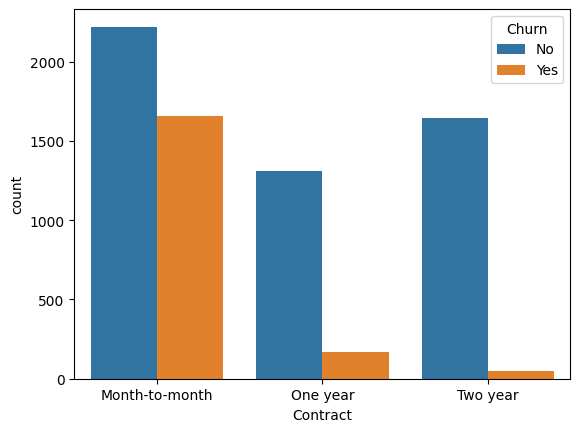

In [38]:
sns.countplot(data=df,x="Contract",hue="Churn")

In [39]:
#Numerical features

In [40]:
num_cols=["tenure","MonthlyCharges","TotalCharges"]

In [41]:
df.groupby("Churn")[num_cols].describe()

tenure                                                     \
        count       mean        std  min   25%   50%   75%   max   
Churn                                                              
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      MonthlyCharges             ...               TotalCharges               \
               count       mean  ...   75%     max        count         mean   
Churn                            ...                                           
No            5174.0  61.265124  ...  88.4  118.75       5163.0  2555.344141   
Yes           1869.0  74.441332  ...  94.2  118.35       1869.0  1531.796094   

                                                                
               std    min      25%      50%       75%      max  
Churn                                                           
No     2329.456984  18.80  577.825  1683.60  4264.125  8672.45  
Yes    1890.822994  18.85  134.500   703.55  2331.300  8684.80  

[2 rows x 24 columns]

In [42]:
df.groupby("Churn")[num_cols].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2555.344141
Yes,17.979133,74.441332,1531.796094


<Axes: xlabel='Churn', ylabel='tenure'>

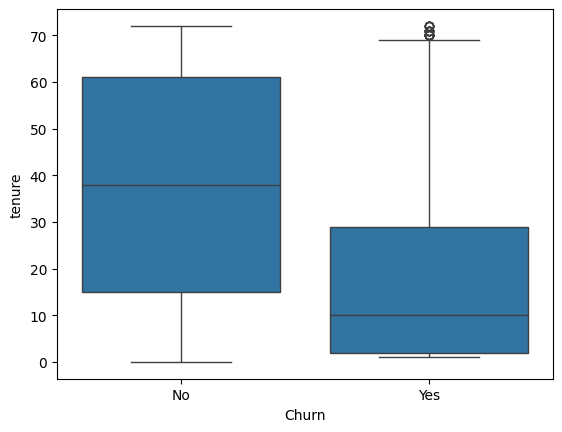

In [43]:
sns.boxplot(data=df,x="Churn",y="tenure")

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

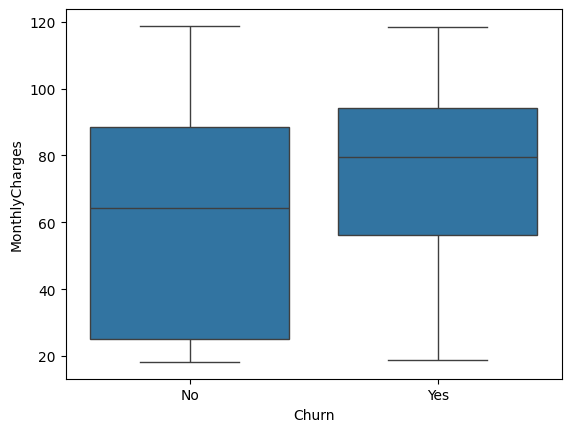

In [44]:
sns.boxplot(data=df,x="Churn",y="MonthlyCharges")

<Axes: xlabel='Churn', ylabel='TotalCharges'>

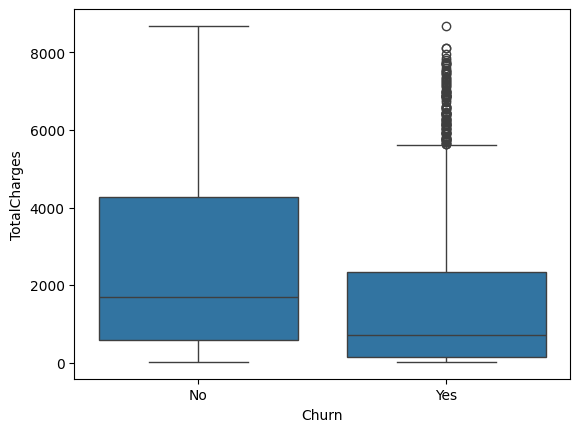

In [45]:
sns.boxplot(data=df,x="Churn",y="TotalCharges")

<Axes: xlabel='tenure', ylabel='Count'>

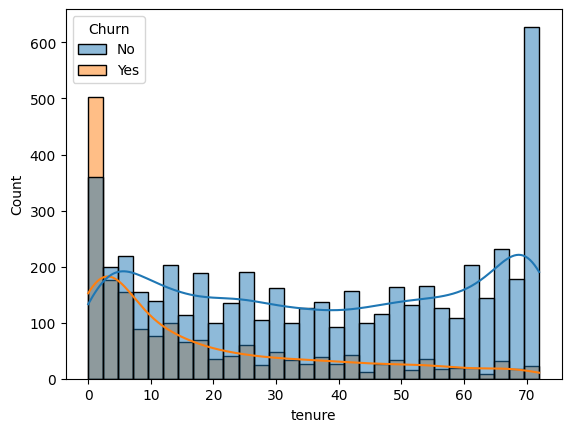

In [46]:
sns.histplot(data=df,x="tenure",hue="Churn",kde=True,bins=30)

<Axes: xlabel='tenure', ylabel='TotalCharges'>

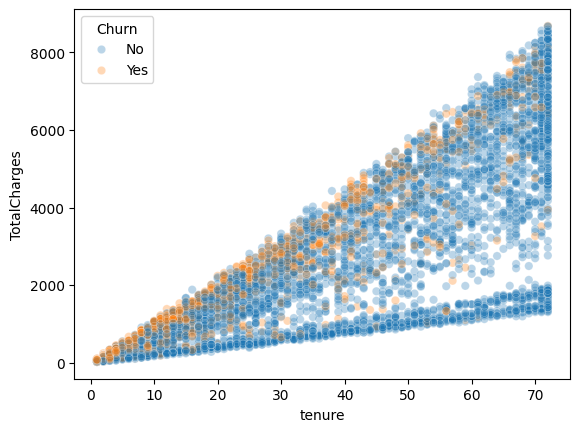

In [47]:
sns.scatterplot(data=df,x="tenure",y="TotalCharges",hue="Churn",alpha=0.3)

<Axes: xlabel='TotalCharges', ylabel='MonthlyCharges'>

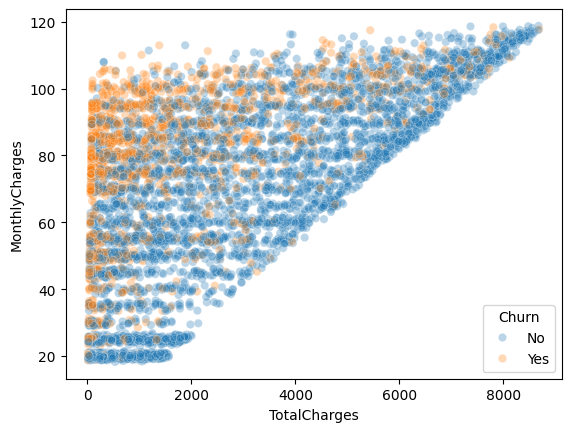

In [48]:
sns.scatterplot(data=df,x="TotalCharges",y="MonthlyCharges",hue="Churn",alpha=0.3)

In [49]:
#Multivariate Analysis

In [50]:
pd.crosstab([df["InternetService"],df["Contract"]],df["Churn"],normalize="index")*100

Churn                                  No        Yes
InternetService Contract                            
DSL             Month-to-month  67.784137  32.215863
                One year        90.701754   9.298246
                Two year        98.089172   1.910828
Fiber optic     Month-to-month  45.394737  54.605263
                One year        80.705009  19.294991
                Two year        92.773893   7.226107
No              Month-to-month  81.106870  18.893130
                One year        97.527473   2.472527
                Two year        99.216301   0.783699

In [51]:
df["TenureGroup"]=pd.cut(df["tenure"],bins=[0,12,24,48,72],labels=["0-12","13-24","25-48","49-72"],include_lowest=True)

In [52]:
pd.crosstab([df["TenureGroup"],df["Contract"]],df["Churn"],normalize="index")*100

Churn                               No        Yes
TenureGroup Contract                             
0-12        Month-to-month   48.645938  51.354062
            One year         89.516129  10.483871
            Two year        100.000000   0.000000
13-24       Month-to-month   62.279512  37.720488
            One year         91.878173   8.121827
            Two year        100.000000   0.000000
25-48       Month-to-month   67.082294  32.917706
            One year         89.382239  10.617761
            Two year         97.810219   2.189781
49-72       Month-to-month   73.976608  26.023392
            One year         87.066246  12.933754
            Two year         96.674584   3.325416

In [53]:
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [54]:
df["ChargeGroup"]=pd.qcut(df["MonthlyCharges"],q=4,labels=["Low","Medium-Low","Medium-High","High"])

In [55]:
pd.crosstab([df["Contract"],df["ChargeGroup"]],df["Churn"],normalize="index")*100

Churn                              No        Yes
Contract       ChargeGroup                      
Month-to-month Low          74.965422  25.034578
               Medium-Low   64.382326  35.617674
               Medium-High  46.717818  53.282182
               High         47.816092  52.183908
One year       Low          96.954315   3.045685
               Medium-Low   91.374663   8.625337
               Medium-High  88.931298  11.068702
               High         79.147982  20.852018
Two year       Low          99.224806   0.775194
               Medium-Low   97.552448   2.447552
               Medium-High  98.447205   1.552795
               High         92.986425   7.013575

In [56]:
pd.crosstab([df["Contract"],df["TenureGroup"]],df["Churn"],normalize="index")*100

Churn                               No        Yes
Contract       TenureGroup                       
Month-to-month 0-12          48.645938  51.354062
               13-24         62.279512  37.720488
               25-48         67.082294  32.917706
               49-72         73.976608  26.023392
One year       0-12          89.516129  10.483871
               13-24         91.878173   8.121827
               25-48         89.382239  10.617761
               49-72         87.066246  12.933754
Two year       0-12         100.000000   0.000000
               13-24        100.000000   0.000000
               25-48         97.810219   2.189781
               49-72         96.674584   3.325416

In [57]:
pd.crosstab([df["Contract"],df["TenureGroup"],df["ChargeGroup"]],df["Churn"],normalize="index")*100

Churn                                           No        Yes
Contract       TenureGroup ChargeGroup                       
Month-to-month 0-12        Low           70.270270  29.729730
                           Medium-Low    54.518072  45.481928
                           Medium-High   32.608696  67.391304
                           High          22.897196  77.102804
               13-24       Low           86.842105  13.157895
                           Medium-Low    73.232323  26.767677
                           Medium-High   55.510204  44.489796
                           High          43.888889  56.111111
               25-48       Low           86.585366  13.414634
                           Medium-Low    83.783784  16.216216
                           Medium-High   60.655738  39.344262
                           High          56.357388  43.642612
               49-72       Low           88.888889  11.111111
                           Medium-Low    83.870968  16.129032
                           Medium-High   80.232558  19.767442
                           High          67.027027  32.972973
One year       0-12        Low           93.975904   6.024096
                           Medium-Low    82.142857  17.857143
                           Medium-High   85.714286  14.285714
                           High          66.666667  33.333333
               13-24       Low           98.947368   1.052632
                           Medium-Low    87.301587  12.698413
                           Medium-High   88.888889  11.111111
                           High          66.666667  33.333333
               25-48       Low           97.122302   2.877698
                           Medium-Low    92.763158   7.236842
                           Medium-High   85.321101  14.678899
                           High          79.661017  20.338983
               49-72       Low           97.402597   2.597403
                           Medium-Low    93.750000   6.250000
                           Medium-High   92.436975   7.563025
                           High          79.677419  20.322581
Two year       0-12        Low          100.000000   0.000000
                           Medium-Low   100.000000   0.000000
                           Medium-High  100.000000   0.000000
               13-24       Low          100.000000   0.000000
                           Medium-Low   100.000000   0.000000
                           Medium-High  100.000000   0.000000
                           High         100.000000   0.000000
               25-48       Low           98.765432   1.234568
                           Medium-Low    97.674419   2.325581
                           Medium-High   97.142857   2.857143
                           High          94.117647   5.882353
               49-72       Low           99.178082   0.821918
                           Medium-Low    97.222222   2.777778
                           Medium-High   98.550725   1.449275
                           High          92.857143   7.142857

In [58]:
#Service Adaption

In [59]:
service_cols=["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

In [60]:
df["ServiceCount"]=(df[service_cols].eq("Yes").sum(axis=1))

In [61]:
df.groupby("ServiceCount")["Churnflag"].mean()*100

ServiceCount
0    21.406039
1    45.755694
2    35.818006
3    27.370304
4    22.300469
5    12.434326
6     5.281690
Name: Churnflag, dtype: float64

In [62]:
#high risk customer segments

In [63]:
df["HighRiskSegment"]=(df["tenure"]<=12)&(df["Contract"]=="Month-to_month")&(df["MonthlyCharges"]>df["MonthlyCharges"].median())

In [64]:
pd.crosstab(df["HighRiskSegment"],df["Churn"],normalize="index")*100

Churn,No,Yes
HighRiskSegment,,
False,73.463013,26.536987


In [65]:
#visualize

<Axes: xlabel='TenureGroup', ylabel='Churnflag'>

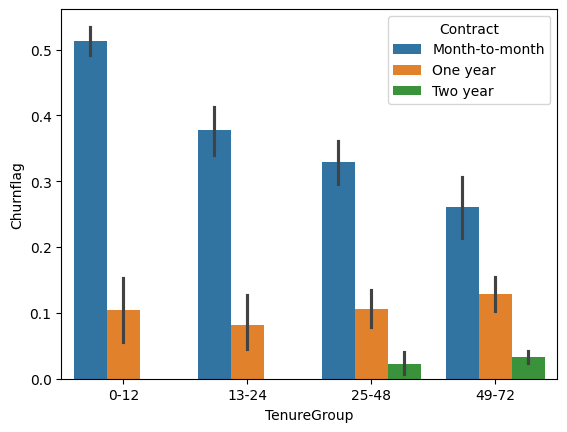

In [66]:
sns.barplot(data=df,x="TenureGroup",y="Churnflag",hue="Contract")

In [67]:
ct=pd.crosstab([df["Contract"],df["InternetService"]],df["Churn"],normalize="index")*100

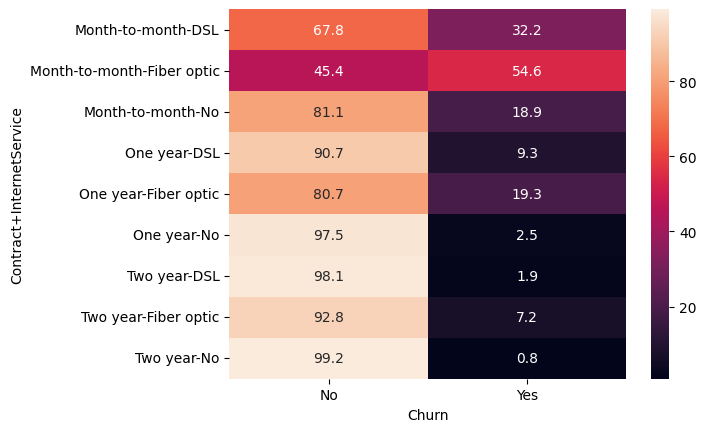

In [68]:
sns.heatmap(ct,annot=True,fmt='.1f')
plt.ylabel("Contract+InternetService")
plt.xlabel("Churn")
plt.show()

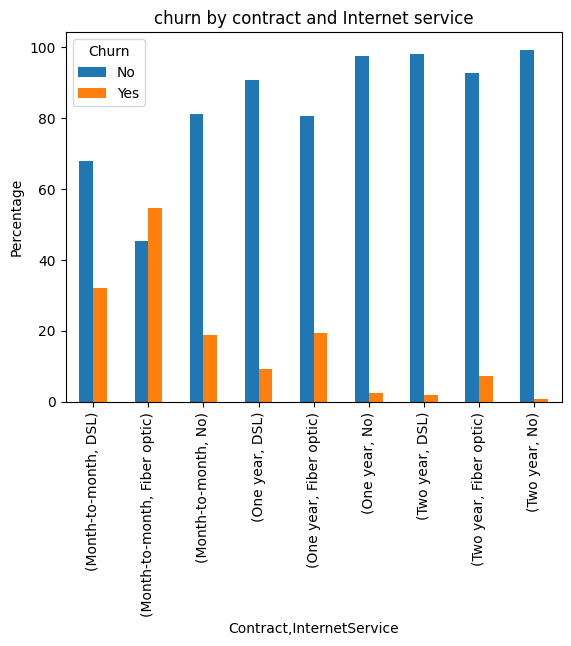

In [69]:
ct.plot(kind="bar")
plt.ylabel("Percentage")
plt.title("churn by contract and Internet service")
plt.show()

<Axes: xlabel='Contract'>

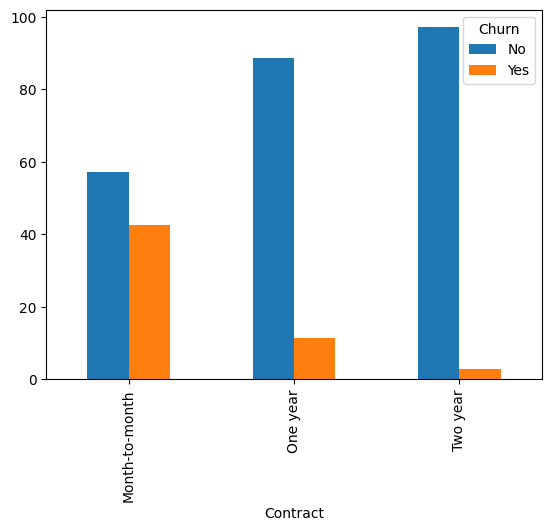

In [70]:
ct=pd.crosstab(df["Contract"],df["Churn"],normalize="index")*100
ct.plot(kind="bar")

In [71]:
#feature engineering

In [72]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churnflag',
       'TenureGroup', 'ChargeGroup', 'ServiceCount', 'HighRiskSegment'],
      dtype='object')

In [73]:
df.drop("customerID",axis=1,inplace=True)

In [74]:
df.groupby("ServiceCount")["Churnflag"].mean()*100

ServiceCount
0    21.406039
1    45.755694
2    35.818006
3    27.370304
4    22.300469
5    12.434326
6     5.281690
Name: Churnflag, dtype: float64

In [75]:
num_cols=df.select_dtypes(include="number").columns
cat_cols=df.select_dtypes(include="object").columns

In [76]:
df.isna().sum()[df.isna().sum()>0]

TotalCharges    11
dtype: int64

In [77]:
df[df["TotalCharges"].isna()][["tenure","MonthlyCharges","TotalCharges","Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [78]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [79]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [80]:
df["TotalCharges"]=df["TotalCharges"].fillna(0)

In [81]:
X=df.drop(columns=["Churn","Churnflag"])
y=df["Churnflag"]

In [82]:
X.shape

(7043, 23)

In [83]:
y.shape

(7043,)

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [86]:
X_train.shape

(5634, 23)

In [87]:
y_train.value_counts(normalize=True)

Churnflag
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [88]:
y_test.value_counts(normalize=True)

Churnflag
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [89]:
numeric_features=X_train.select_dtypes(include=["int64","float64"]).columns

In [90]:
cat_features=X_train.select_dtypes(include="object").columns

In [91]:
print("Numeric:",list(numeric_features))

Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount']


In [92]:
print("Categorical_features:",list(cat_features))

Categorical_features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [93]:
num_cols=["tenure","MonthlyCharges"",TotalCharges","serviceCount"]
cat_features=["SeniorCitizen"]+list(X_train.select_dtypes(include="object").columns)

In [94]:
print("Categorical_features:",list(cat_features))

Categorical_features: ['SeniorCitizen', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [95]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [96]:
preprocessor=ColumnTransformer(transformers=[("num",StandardScaler(),numeric_features),("cat",OneHotEncoder(handle_unknown="ignore",drop="first"),cat_features)])

In [97]:
X_train_processed=preprocessor.fit_transform(X_train)

In [98]:
X_test_processed = preprocessor.transform(X_test)

In [99]:
X_train_processed.shape

(5634, 32)

In [100]:
X_train_processed

array([[-0.44177295,  0.10237124, -0.52197565, ...,  0.        ,
         1.        ,  0.        ],
       [-0.44177295, -0.71174346,  0.33747781, ...,  0.        ,
         0.        ,  1.        ],
       [-0.44177295, -0.79315493, -0.80901319, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 2.2636062 , -0.30468611,  1.25666162, ...,  0.        ,
         0.        ,  1.        ],
       [-0.44177295, -0.34539184, -1.47766135, ...,  1.        ,
         0.        ,  0.        ],
       [-0.44177295, -1.07809507, -1.46936546, ...,  0.        ,
         0.        ,  1.        ]], shape=(5634, 32))

In [101]:
preprocessor.get_feature_names_out()

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'num__ServiceCount', 'cat__SeniorCitizen_1',
       'cat__gender_Male', 'cat__Partner_Yes', 'cat__Dependents_Yes',
       'cat__PhoneService_Yes', 'cat__MultipleLines_No phone service',
       'cat__MultipleLines_Yes', 'cat__InternetService_Fiber optic',
       'cat__InternetService_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No internet service',
       'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No internet service', 'cat__StreamingTV_Yes',
       'cat__StreamingMovies_No internet service',
       'cat__StreamingMovies_Yes', 'cat__Contract_One year',
       'cat__Contract_Two year', 'cat__PaperlessBilling_Yes',
       'cat__PaymentMethod_Credit card (automatic)',
  

In [102]:
len(preprocessor.get_feature_names_out())

32

In [103]:
from sklearn.linear_model import LogisticRegression

In [104]:
lr=LogisticRegression(max_iter=1000,random_state=42)

In [105]:
lr.fit(X_train_processed,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [106]:
y_pred=lr.predict(X_test_processed)

In [107]:
y_prob=lr.predict_proba(X_test_processed)[:,1]

In [108]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

In [109]:
accuracy_score(y_test,y_pred)

0.8048261178140526

In [110]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [111]:
cm=confusion_matrix(y_test,y_pred)

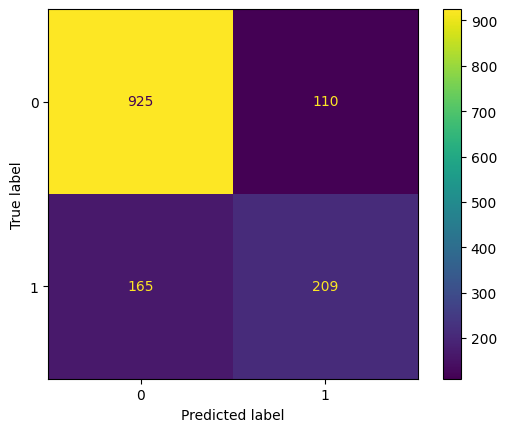

In [112]:
ConfusionMatrixDisplay(cm).plot()

In [113]:
lr_weighted=LogisticRegression(class_weight="balanced",max_iter=1000,random_state=42)

In [114]:
lr_weighted.fit(X_train_processed,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [115]:
y_pred_weighted=lr_weighted.predict(X_test_processed)

In [116]:
print(classification_report(y_test,y_pred_weighted))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [117]:
cm_weighted=confusion_matrix(y_test,y_pred_weighted)

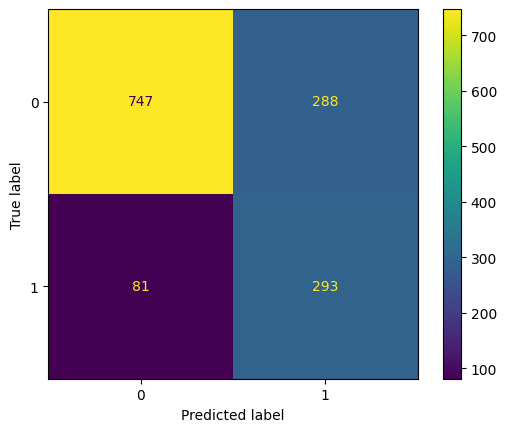

In [118]:
ConfusionMatrixDisplay(cm_weighted).plot()

In [119]:
print("Baseline")
print(classification_report(y_test,y_pred))

Baseline
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [120]:
print("Weighted")
print(classification_report(y_test,y_pred_weighted))

Weighted
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [121]:
y_prob=lr.predict_proba(X_test_processed)[:,1]

In [122]:
y_prob

array([0.04564181, 0.68343682, 0.05946554, ..., 0.15521341, 0.00445974,
       0.00644004], shape=(1409,))

In [123]:
y_prob_weighted=lr_weighted.predict_proba(X_test_processed)[:,1]

In [124]:
y_prob_weighted

array([0.11865423, 0.8514959 , 0.14912845, ..., 0.33639595, 0.01325243,
       0.01803733], shape=(1409,))

In [125]:
#threshold tuning

In [126]:
from sklearn.metrics import precision_score,recall_score

In [127]:
thresholds=[0.2,0.3,0.4,0.5,0.6,0.7]
for threshold in thresholds:
    y_pred_threshold=(y_prob_weighted>= threshold).astype(int)
    print(threshold,"precision:",round(precision_score(y_test,y_pred_threshold),2),
   "Recall:",round(recall_score(y_test,y_pred_threshold),2))

0.2 precision: 0.39 Recall: 0.96
0.3 precision: 0.43 Recall: 0.93
0.4 precision: 0.47 Recall: 0.87
0.5 precision: 0.5 Recall: 0.78
0.6 precision: 0.54 Recall: 0.7
0.7 precision: 0.6 Recall: 0.6


In [128]:
for threshold in thresholds:
    y_pred_threshold=(y_prob_weighted>= threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_test,y_pred_threshold).ravel()
    customers_targeted=tp+fp
    retention_cost=200
    revenue_at_risk=2000
    campign_cost=customers_targeted*retention_cost
    revenue_protected=tp*revenue_at_risk
    net_benefit=revenue_protected-campign_cost
    print(f"Threshold:{threshold}|"f"TN:{tn},FP:{fp},FN:{fn},TP:{tp}")

Threshold:0.2|TN:468,FP:567,FN:14,TP:360
Threshold:0.3|TN:576,FP:459,FN:27,TP:347
Threshold:0.4|TN:664,FP:371,FN:50,TP:324
Threshold:0.5|TN:747,FP:288,FN:81,TP:293
Threshold:0.6|TN:810,FP:225,FN:111,TP:263
Threshold:0.7|TN:886,FP:149,FN:149,TP:225


In [129]:
results=[]
for threshold in thresholds:
    y_pred_threshold=(y_prob_weighted>=threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_test,y_pred_threshold).ravel()
    customers_targeted=tp+fp
    campign_cost=customers_targeted*retention_cost
    revenue_protected=tp*revenue_at_risk
    net_benefit=revenue_protected-campign_cost
    roi_percent=(net_benefit/campign_cost)*100
    results.append({
        "Threshold":threshold,
        "TP":tp,
        "FP":fp,
        "TN":tn,
        "FN":fn,
        "Customers Targeted":customers_targeted,
        "Campign_Cost":campign_cost,
        "revenue_protected":revenue_protected,
        "net_benefit":net_benefit,
        "ROI %":roi_percent
    })

In [130]:
roi_df=pd.DataFrame(results)
roi_df

,Threshold,TP,FP,TN,FN,Customers Targeted,Campign_Cost,revenue_protected,net_benefit,ROI %
0,0.2,360,567,468,14,927,185400,720000,534600,288.349515
1,0.3,347,459,576,27,806,161200,694000,532800,330.521092
2,0.4,324,371,664,50,695,139000,648000,509000,366.187050
3,0.5,293,288,747,81,581,116200,586000,469800,404.302926
4,0.6,263,225,810,111,488,97600,526000,428400,438.934426
5,0.7,225,149,886,149,374,74800,450000,375200,501.604278


In [131]:
success_rate=0.3

In [132]:
revenue_protected=tp*success_rate*revenue_at_risk

In [133]:
results=[]
for threshold in thresholds:
    y_pred_threshold=(y_prob_weighted>=threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_test,y_pred_threshold).ravel()
    customers_targeted=tp+fp
    campign_cost=customers_targeted*retention_cost
    revenue_protected=tp*success_rate*revenue_at_risk
    net_benefit=revenue_protected-campign_cost
    roi_percent=(net_benefit/campign_cost)*100
    results.append({
        "Threshold":threshold,
        "TP":tp,
        "FP":fp,
        "TN":tn,
        "FN":fn,
        "Customers Targeted":customers_targeted,
        "Campign_Cost":campign_cost,
        "revenue_protected":revenue_protected,
        "net_benefit":net_benefit,
        "ROI %":roi_percent
    })

In [134]:
roi_df=pd.DataFrame(results)

In [135]:
roi_df

,Threshold,TP,FP,TN,FN,Customers Targeted,Campign_Cost,revenue_protected,net_benefit,ROI %
0,0.2,360,567,468,14,927,185400,216000.0,30600.0,16.504854
1,0.3,347,459,576,27,806,161200,208200.0,47000.0,29.156328
2,0.4,324,371,664,50,695,139000,194400.0,55400.0,39.856115
3,0.5,293,288,747,81,581,116200,175800.0,59600.0,51.290878
4,0.6,263,225,810,111,488,97600,157800.0,60200.0,61.680328
5,0.7,225,149,886,149,374,74800,135000.0,60200.0,80.481283


In [136]:
#sensitivity analysis

In [137]:
retention_costs=[100,200,300,400,500]
success_rates=[0.2,0.3,0.4]
revenue_at_risks=[1000,2000,3000,4000,5000]

In [138]:
sensitivity_results=[]
for retention_cost in retention_costs:
 for threshold in thresholds:
    y_pred_threshold=(y_prob_weighted>=threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_test,y_pred_threshold).ravel()
    customers_targeted=tp+fp
    campign_cost=customers_targeted*retention_cost
    revenue_protected=tp*success_rate*revenue_at_risk
    net_benefit=revenue_protected-campign_cost
    roi_percent=(net_benefit/campign_cost)*100
    sensitivity_results.append({
        "Retention_cost":retention_cost,
        "Threshold":threshold,
        "TP":tp,
        "FP":fp,
        "TN":tn,
        "FN":fn,
        "Customers Targeted":customers_targeted,
        "Campign_Cost":campign_cost,
        "revenue_protected":revenue_protected,
        "net_benefit":net_benefit,
        "ROI %":roi_percent
    })

In [139]:
sensitivity_df=pd.DataFrame(sensitivity_results)

In [140]:
sensitivity_df

,Retention_cost,Threshold,TP,FP,TN,FN,Customers Targeted,Campign_Cost,revenue_protected,net_benefit,ROI %
0,100,0.2,360,567,468,14,927,92700,216000.0,123300.0,133.009709
1,100,0.3,347,459,576,27,806,80600,208200.0,127600.0,158.312655
2,100,0.4,324,371,664,50,695,69500,194400.0,124900.0,179.712230
3,100,0.5,293,288,747,81,581,58100,175800.0,117700.0,202.581756
4,100,0.6,263,225,810,111,488,48800,157800.0,109000.0,223.360656
5,100,0.7,225,149,886,149,374,37400,135000.0,97600.0,260.962567
6,200,0.2,360,567,468,14,927,185400,216000.0,30600.0,16.504854
7,200,0.3,347,459,576,27,806,161200,208200.0,47000.0,29.156328
8,200,0.4,324,371,664,50,695,139000,194400.0,55400.0,39.856115
9,200,0.5,293,288,747,81,581,116200,175800.0,59600.0,51.290878


In [141]:
sensitivity_df.loc[sensitivity_df.groupby("Retention_cost")["net_benefit"].idxmax()]

,Retention_cost,Threshold,TP,FP,TN,FN,Customers Targeted,Campign_Cost,revenue_protected,net_benefit,ROI %
1,100,0.3,347,459,576,27,806,80600,208200.0,127600.0,158.312655
11,200,0.7,225,149,886,149,374,74800,135000.0,60200.0,80.481283
17,300,0.7,225,149,886,149,374,112200,135000.0,22800.0,20.320856
23,400,0.7,225,149,886,149,374,149600,135000.0,-14600.0,-9.759358
29,500,0.7,225,149,886,149,374,187000,135000.0,-52000.0,-27.807487


In [142]:
sensitivity_results=[]
for success_rate in success_rates:
 for threshold in thresholds:
    y_pred_threshold=(y_prob_weighted>=threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_test,y_pred_threshold).ravel()
    customers_targeted=tp+fp
    campign_cost=customers_targeted*retention_cost
    revenue_protected=tp*success_rate*revenue_at_risk
    net_benefit=revenue_protected-campign_cost
    roi_percent=(net_benefit/campign_cost)*100
    sensitivity_results.append({
        "Success_rate":success_rate,
        "Threshold":threshold,
        "TP":tp,
        "FP":fp,
        "TN":tn,
        "FN":fn,
        "Customers Targeted":customers_targeted,
        "Campign_Cost":campign_cost,
        "revenue_protected":revenue_protected,
        "net_benefit":net_benefit,
        "ROI %":roi_percent
    })

In [143]:
sensitivity_df=pd.DataFrame(sensitivity_results)

In [144]:
sensitivity_df

,Success_rate,Threshold,TP,FP,TN,FN,Customers Targeted,Campign_Cost,revenue_protected,net_benefit,ROI %
0,0.2,0.2,360,567,468,14,927,463500,144000.0,-319500.0,-68.932039
1,0.2,0.3,347,459,576,27,806,403000,138800.0,-264200.0,-65.558313
2,0.2,0.4,324,371,664,50,695,347500,129600.0,-217900.0,-62.705036
3,0.2,0.5,293,288,747,81,581,290500,117200.0,-173300.0,-59.655766
4,0.2,0.6,263,225,810,111,488,244000,105200.0,-138800.0,-56.885246
5,0.2,0.7,225,149,886,149,374,187000,90000.0,-97000.0,-51.871658
6,0.3,0.2,360,567,468,14,927,463500,216000.0,-247500.0,-53.398058
7,0.3,0.3,347,459,576,27,806,403000,208200.0,-194800.0,-48.337469
8,0.3,0.4,324,371,664,50,695,347500,194400.0,-153100.0,-44.057554
9,0.3,0.5,293,288,747,81,581,290500,175800.0,-114700.0,-39.483649


In [145]:
sensitivity_df.loc[sensitivity_df.groupby("Success_rate")["net_benefit"].idxmax()]

,Success_rate,Threshold,TP,FP,TN,FN,Customers Targeted,Campign_Cost,revenue_protected,net_benefit,ROI %
5,0.2,0.7,225,149,886,149,374,187000,90000.0,-97000.0,-51.871658
11,0.3,0.7,225,149,886,149,374,187000,135000.0,-52000.0,-27.807487
17,0.4,0.7,225,149,886,149,374,187000,180000.0,-7000.0,-3.743316


In [146]:
sensitivity_results=[]
for retention_cost in retention_costs:
    for success_rate in success_rates:
        for revenue_at_risk in revenue_at_risks:
            for threshold in thresholds:
                 y_pred_threshold=(y_prob_weighted>=threshold).astype(int)
                 tn,fp,fn,tp=confusion_matrix(y_test,y_pred_threshold).ravel()
                 customers_targeted=tp+fp
                 campign_cost=customers_targeted*retention_cost
                 revenue_protected=tp*success_rate*revenue_at_risk
                 net_benefit=revenue_protected-campign_cost
                 roi_percent=(net_benefit/campign_cost)*100
                 sensitivity_results.append({
                     "Retention_cost":retention_cost,
                     "Revenue_AT_Risk":revenue_at_risk,
                     "Success_rate":success_rate,
                     "Threshold":threshold,
                     "TP":tp,
                     "FP":fp,
                     "TN":tn,
                     "FN":fn,
                     "Customers Targeted":customers_targeted,
                     "Campign_Cost":campign_cost,
                     "revenue_protected":revenue_protected,
                     "net_benefit":net_benefit,
                     "ROI %":roi_percent
    })
    

In [147]:
sensitivity_df=pd.DataFrame(sensitivity_results)

In [148]:
sensitivity_df

,Retention_cost,Revenue_AT_Risk,Success_rate,Threshold,TP,FP,TN,FN,Customers Targeted,Campign_Cost,revenue_protected,net_benefit,ROI %
0,100,1000,0.2,0.2,360,567,468,14,927,92700,72000.0,-20700.0,-22.330097
1,100,1000,0.2,0.3,347,459,576,27,806,80600,69400.0,-11200.0,-13.895782
2,100,1000,0.2,0.4,324,371,664,50,695,69500,64800.0,-4700.0,-6.762590
3,100,1000,0.2,0.5,293,288,747,81,581,58100,58600.0,500.0,0.860585
4,100,1000,0.2,0.6,263,225,810,111,488,48800,52600.0,3800.0,7.786885
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,500,5000,0.4,0.3,347,459,576,27,806,403000,694000.0,291000.0,72.208437
446,500,5000,0.4,0.4,324,371,664,50,695,347500,648000.0,300500.0,86.474820
447,500,5000,0.4,0.5,293,288,747,81,581,290500,586000.0,295500.0,101.721170
448,500,5000,0.4,0.6,263,225,810,111,488,244000,526000.0,282000.0,115.573770


In [149]:
baseline=sensitivity_df[(sensitivity_df["Retention_cost"]==200) & (sensitivity_df["Success_rate"]==0.3) & (sensitivity_df["Revenue_AT_Risk"]==3000)]

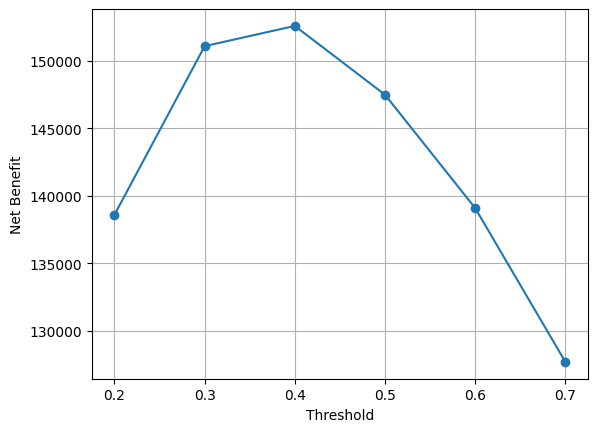

In [150]:
plt.plot(
    baseline["Threshold"],
    baseline["net_benefit"],
    marker="o"
)
plt.xlabel("Threshold")
plt.ylabel("Net Benefit")
plt.grid()

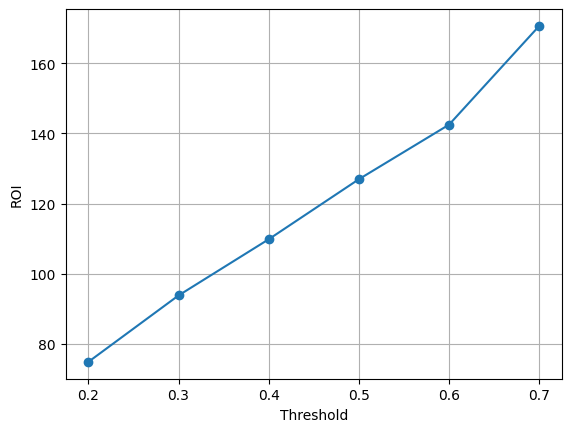

In [151]:
plt.plot(
    baseline["Threshold"],
    baseline["ROI %"],
    marker="o"
)
plt.xlabel("Threshold")
plt.ylabel("ROI")
plt.grid()

In [152]:
best_scenarios=sensitivity_df.loc[sensitivity_df.groupby(["Retention_cost","Success_rate","Revenue_AT_Risk"])["net_benefit"].idxmax()]

In [153]:
best_scenarios[
    [
        "Retention_cost",
        "Success_rate",
        "Revenue_AT_Risk",
        "Threshold",
        "net_benefit",
        "ROI %"
    ]
]

,Retention_cost,Success_rate,Revenue_AT_Risk,Threshold,net_benefit,ROI %
5,100,0.2,1000,0.7,7600.0,20.320856
8,100,0.2,2000,0.4,60100.0,86.474820
13,100,0.2,3000,0.3,127600.0,158.312655
19,100,0.2,4000,0.3,197000.0,244.416873
24,100,0.2,5000,0.2,267300.0,288.349515
...,...,...,...,...,...,...
425,500,0.4,1000,0.7,-97000.0,-51.871658
431,500,0.4,2000,0.7,-7000.0,-3.743316
437,500,0.4,3000,0.7,83000.0,44.385027
441,500,0.4,4000,0.5,178300.0,61.376936


In [154]:
best_overall=sensitivity_df.loc[sensitivity_df["net_benefit"].idxmax()]
best_overall

Retention_cost           100.000000
Revenue_AT_Risk         5000.000000
Success_rate               0.400000
Threshold                  0.200000
TP                       360.000000
FP                       567.000000
TN                       468.000000
FN                        14.000000
Customers Targeted       927.000000
Campign_Cost           92700.000000
revenue_protected     720000.000000
net_benefit           627300.000000
ROI %                    676.699029
Name: 84, dtype: float64

In [155]:
final_scenario=sensitivity_df[(sensitivity_df["Retention_cost"]==best_overall["Retention_cost"])&(sensitivity_df["Revenue_AT_Risk"]==best_overall["Revenue_AT_Risk"])&(sensitivity_df["Success_rate"]==best_overall["Success_rate"])]

Text(0.5, 1.0, 'Net_benefit VS Classification threshold')

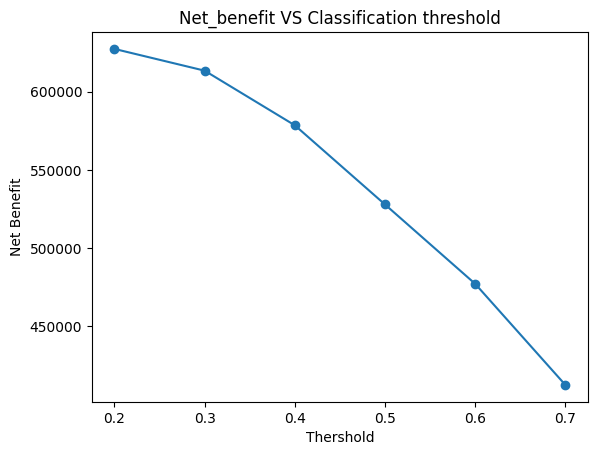

In [156]:
plt.plot(final_scenario["Threshold"],final_scenario["net_benefit"],marker='o')
plt.xlabel("Thershold")
plt.ylabel("Net Benefit")
plt.title('Net_benefit VS Classification threshold')

In [157]:
heatmap_data=best_scenarios[best_scenarios["Success_rate"]==0.3]

In [158]:
heatmap_data

,Retention_cost,Revenue_AT_Risk,Success_rate,Threshold,TP,FP,TN,FN,Customers Targeted,Campign_Cost,revenue_protected,net_benefit,ROI %
35,100,1000,0.3,0.7,225,149,886,149,374,37400,67500.0,30100.0,80.481283
37,100,2000,0.3,0.3,347,459,576,27,806,80600,208200.0,127600.0,158.312655
43,100,3000,0.3,0.3,347,459,576,27,806,80600,312300.0,231700.0,287.468983
48,100,4000,0.3,0.2,360,567,468,14,927,92700,432000.0,339300.0,366.019417
54,100,5000,0.3,0.2,360,567,468,14,927,92700,540000.0,447300.0,482.524272
125,200,1000,0.3,0.7,225,149,886,149,374,74800,67500.0,-7300.0,-9.759358
131,200,2000,0.3,0.7,225,149,886,149,374,74800,135000.0,60200.0,80.481283
134,200,3000,0.3,0.4,324,371,664,50,695,139000,291600.0,152600.0,109.784173
139,200,4000,0.3,0.3,347,459,576,27,806,161200,416400.0,255200.0,158.312655
145,200,5000,0.3,0.3,347,459,576,27,806,161200,520500.0,359300.0,222.890819


In [159]:
pivot=heatmap_data.pivot(index=["Retention_cost","Success_rate"],columns="Revenue_AT_Risk",values="Threshold")

In [160]:
pivot

,Revenue_AT_Risk,1000,2000,3000,4000,5000
Retention_cost,Success_rate,,,,,
100,0.3,0.7,0.3,0.3,0.2,0.2
200,0.3,0.7,0.7,0.4,0.3,0.3
300,0.3,0.7,0.7,0.7,0.4,0.3
400,0.3,0.7,0.7,0.7,0.7,0.4
500,0.3,0.7,0.7,0.7,0.7,0.7


Text(0.5, 1.0, 'Optimal Threshold by Buisiness Assumption')

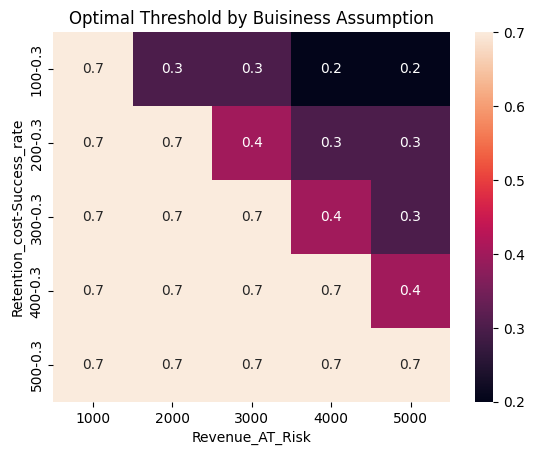

In [161]:
sns.heatmap(pivot,annot=True,fmt=".1f")
plt.title("Optimal Threshold by Buisiness Assumption") #given retention cost and revenue at risk u can now 

In [162]:
sensitivity_df["Customers Targeted"]==(sensitivity_df['TP']+sensitivity_df["FP"])

0      True
1      True
2      True
3      True
4      True
       ... 
445    True
446    True
447    True
448    True
449    True
Length: 450, dtype: bool

In [163]:
assert (
    sensitivity_df["Customers Targeted"]
    == sensitivity_df["TP"] + sensitivity_df["FP"]
).all()

assert (
    sensitivity_df["Campign_Cost"]
    == sensitivity_df["Customers Targeted"] *
       sensitivity_df["Retention_cost"]
).all()

In [164]:
#SHAP

In [165]:
import shap 

In [166]:
explainer=shap.LinearExplainer(lr_weighted,X_train_processed)

In [167]:
shap_values=explainer.shap_values(X_test_processed)

In [168]:
explainer

In [169]:
shap_values

array([[-5.36989010e-02, -1.84461054e+00, -9.07393109e-01, ...,
         1.39756615e-03, -1.24991232e-01, -1.24028489e-02],
       [ 1.38082888e-01,  1.19256658e+00, -6.46096979e-01, ...,
         1.39756615e-03, -1.24991232e-01, -1.24028489e-02],
       [-5.36989010e-02, -3.73477873e-01, -2.36294414e-01, ...,
         1.39756615e-03, -1.24991232e-01, -1.24028489e-02],
       ...,
       [-5.36989010e-02,  1.33493425e+00,  8.48366502e-01, ...,
        -4.91036757e-04, -1.24991232e-01, -1.24028489e-02],
       [-5.36989010e-02, -1.08531626e+00,  8.66224870e-01, ...,
        -4.91036757e-04, -1.24991232e-01, -1.24028489e-02],
       [-5.36989010e-02, -1.84461054e+00, -8.77879805e-02, ...,
        -4.91036757e-04, -1.24991232e-01, -1.24028489e-02]],
      shape=(1409, 32))

In [170]:
feature_names=preprocessor.get_feature_names_out()

shap.summary_plot(shap_values,X_test_processed,feature_names=feature_names)

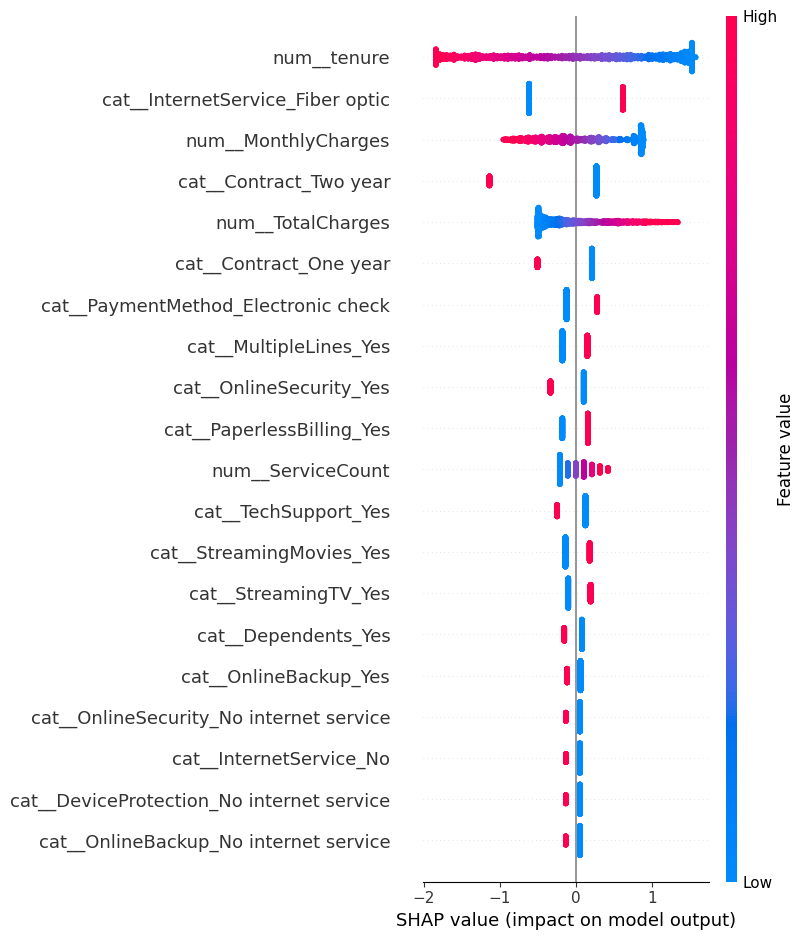

In [171]:
shap.summary_plot(shap_values,X_test_processed,feature_names=feature_names)

In [172]:
#high risk individul customer shap

In [173]:
y_prob=lr_weighted.predict_proba(X_test_processed)[:,1]

In [174]:
customer_idx=y_prob.argmax()

In [175]:
y_prob[customer_idx]

np.float64(0.9378618122170747)

In [176]:
customer_shap=shap_values[customer_idx]

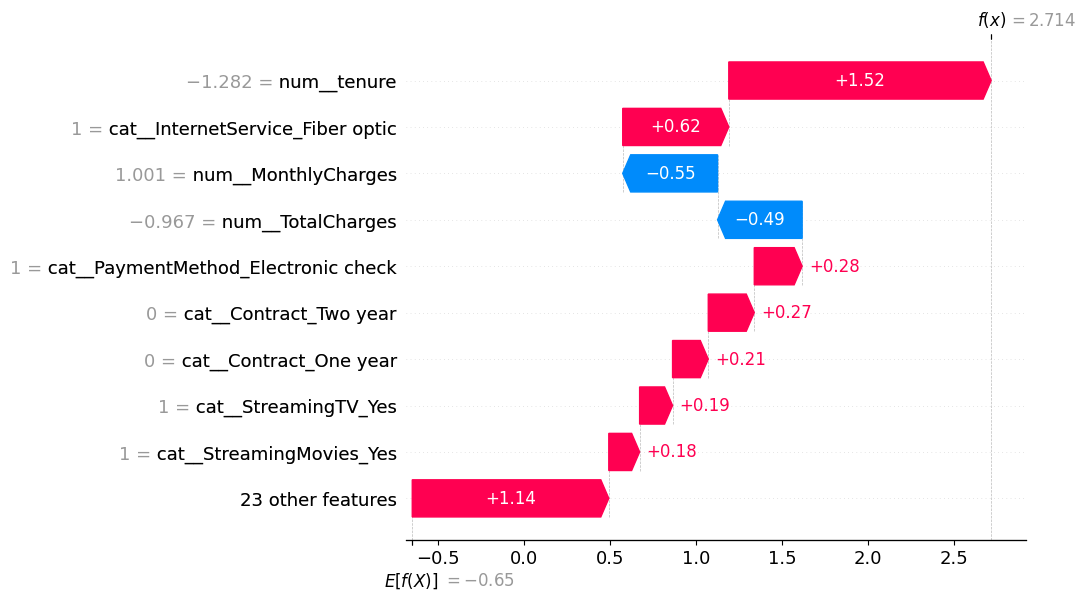

In [177]:
shap.waterfall_plot(shap.Explanation(values=customer_shap,base_values=explainer.expected_value,data=X_test_processed[customer_idx],
                                    feature_names=feature_names))

In [178]:
pd.Series(y_prob).describe()

count    1409.000000
mean        0.415797
std         0.301986
min         0.005505
25%         0.115104
50%         0.393020
75%         0.710269
max         0.937862
dtype: float64

Text(0.5, 1.0, 'distribution of predicted churn probabilities')

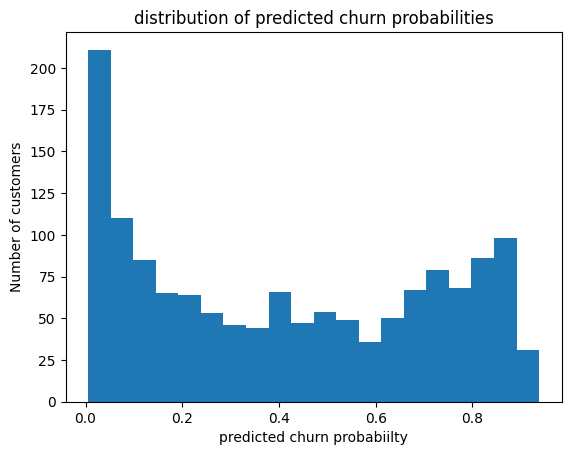

In [179]:
plt.hist(y_prob,bins=20)
plt.xlabel("predicted churn probabiilty")
plt.ylabel("Number of customers")
plt.title("distribution of predicted churn probabilities")

In [180]:
risk_segment=pd.cut(y_prob,bins=[0,0.4,0.7,1],
                   labels=["Low Risk","Medium Risk","High Risk"],include_lowest=True)

In [181]:
risk_segment

['Low Risk', 'High Risk', 'Low Risk', 'Medium Risk', 'Low Risk', ..., 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk']
Length: 1409
Categories (3, object): ['Low Risk' < 'Medium Risk' < 'High Risk']

In [182]:
risk_segment.value_counts().sort_index

<bound method Series.sort_index of Low Risk       714
Medium Risk    321
High Risk      374
Name: count, dtype: int64>

In [183]:
pd.crosstab(risk_segment,y_test,normalize="index")*100

Churnflag,0,1
row_0,,
Low Risk,92.997199,7.002801
Medium Risk,69.158879,30.841121
High Risk,39.839572,60.160428


In [184]:
risk_df=pd.DataFrame({"Risk":risk_segment,"Actual_Churn":y_test})
risk_df.groupby("Risk")["Actual_Churn"].mean()

C:\Users\dell\AppData\Local\Temp\ipykernel_13392\105955965.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_df.groupby("Risk")["Actual_Churn"].mean()


Risk
Low Risk       0.070028
Medium Risk    0.308411
High Risk      0.601604
Name: Actual_Churn, dtype: float64

In [185]:
risk_df["Action"]=risk_df["Risk"].map({"Low Risk":"No intervention","Medium Risk":"Targeted retention intervention","High Risk":"immediate retention intervention"})

In [186]:
risk_df["Action"].value_counts()

Action
No intervention                     714
immediate retention intervention    374
Targeted retention intervention     321
Name: count, dtype: int64